# SILVA Mesh Inference

This lab derives typed center-free relaxation in the linear-Gaussian regime,
verifies the M-matrix certificate, compares against the centralized optimum,
and studies directed admission. The mechanism follows Mesh Inference [[63]](https://jseluis.github.io/silva-networks/paper/references/#ref-63).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[63]](https://jseluis.github.io/silva-networks/paper/references/#ref-63). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from silva_networks import (
    SILVAMeshInference,
    SolverConfig,
    make_mesh_gaussian_dataset,
)

## 1. Typed Anchors, Evidence, and Policy

For receiver $i$ and field $f$,

$$
(\lambda_i+\tau_i+\sum_jw_{ij})z_i^\star-\sum_jw_{ij}z_j^\star
=\lambda_i a_i+\tau_i o_i.
$$

$w_{ij}\geq0$ combines receiver admission and source emission. Fields are
independent typed coordinates; no model parameter or gradient is part of this
wire-level state.

In [3]:
data = make_mesh_gaussian_dataset(nodes=7, fields=3, asymmetric=True)
model = SILVAMeshInference(
    SolverConfig(solver="picard", max_iter=600, tol=1e-8, return_best=True)
)
result = model(
    data.anchors,
    data.anchor_precision,
    data.observations,
    data.observation_precision,
    data.admission,
    emission=data.emission,
    return_result=True,
)
print("distributed/centralized agreement:", float(result.agreement_error))
print("certificate:", result.certificate)
assert result.agreement_error < 5e-5
assert result.certificate.is_z_matrix
assert result.certificate.jacobi_spectral_radius < 1

distributed/centralized agreement: 2.432089729609288e-07
certificate: SILVAMatrixCertificate(is_z_matrix=True, weakly_diagonally_dominant=True, min_real_eigenvalue=0.20780980587005615, jacobi_spectral_radius=0.826240062713623)


## 2. Why the Iteration Converges

The system matrix has positive diagonal and nonpositive off-diagonal entries.
Anchoring makes the reachable component nonsingular. Jacobi relaxation is

$$
z_i^{k+1}=\frac{b_i+\sum_jw_{ij}z_j^k}
{\lambda_i+\tau_i+\sum_jw_{ij}}.
$$

The reported certificate checks the Z-matrix property, weak diagonal
dominance, minimum real eigenvalue, and Jacobi spectral radius.

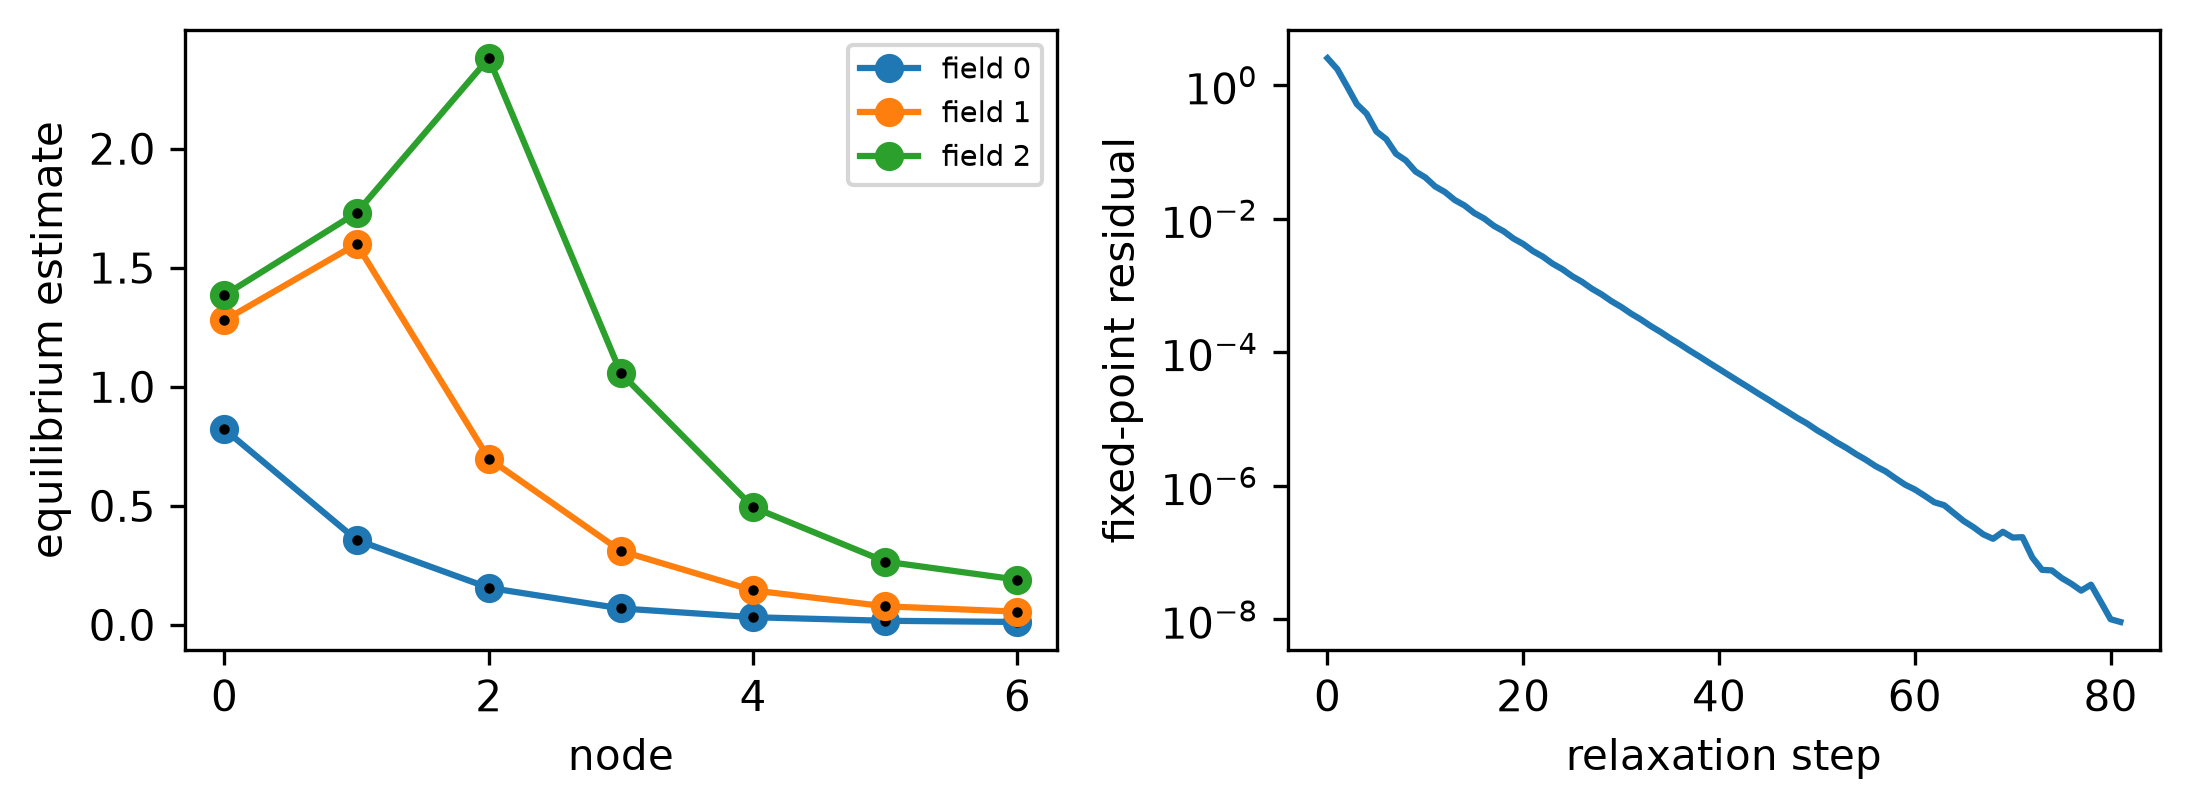

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(7.4, 2.8))
nodes = torch.arange(data.anchors.shape[0])
for field in range(data.anchors.shape[1]):
    axes[0].plot(nodes, result.output[:, field], "o-", label=f"field {field}")
    axes[0].plot(nodes, result.centralized[:, field], "k.", ms=3)
axes[0].set(xlabel="node", ylabel="equilibrium estimate")
axes[0].legend(fontsize=7)
axes[1].semilogy(result.solver_result.residuals)
axes[1].set(xlabel="relaxation step", ylabel="fixed-point residual")
figure.tight_layout()
plt.show()

## 3. Directed Admission Sweep

Asymmetry can remove a common quadratic potential without removing the
M-matrix convergence structure. The sweep below varies one direction while
checking distributed/centralized agreement and the Jacobi rate.

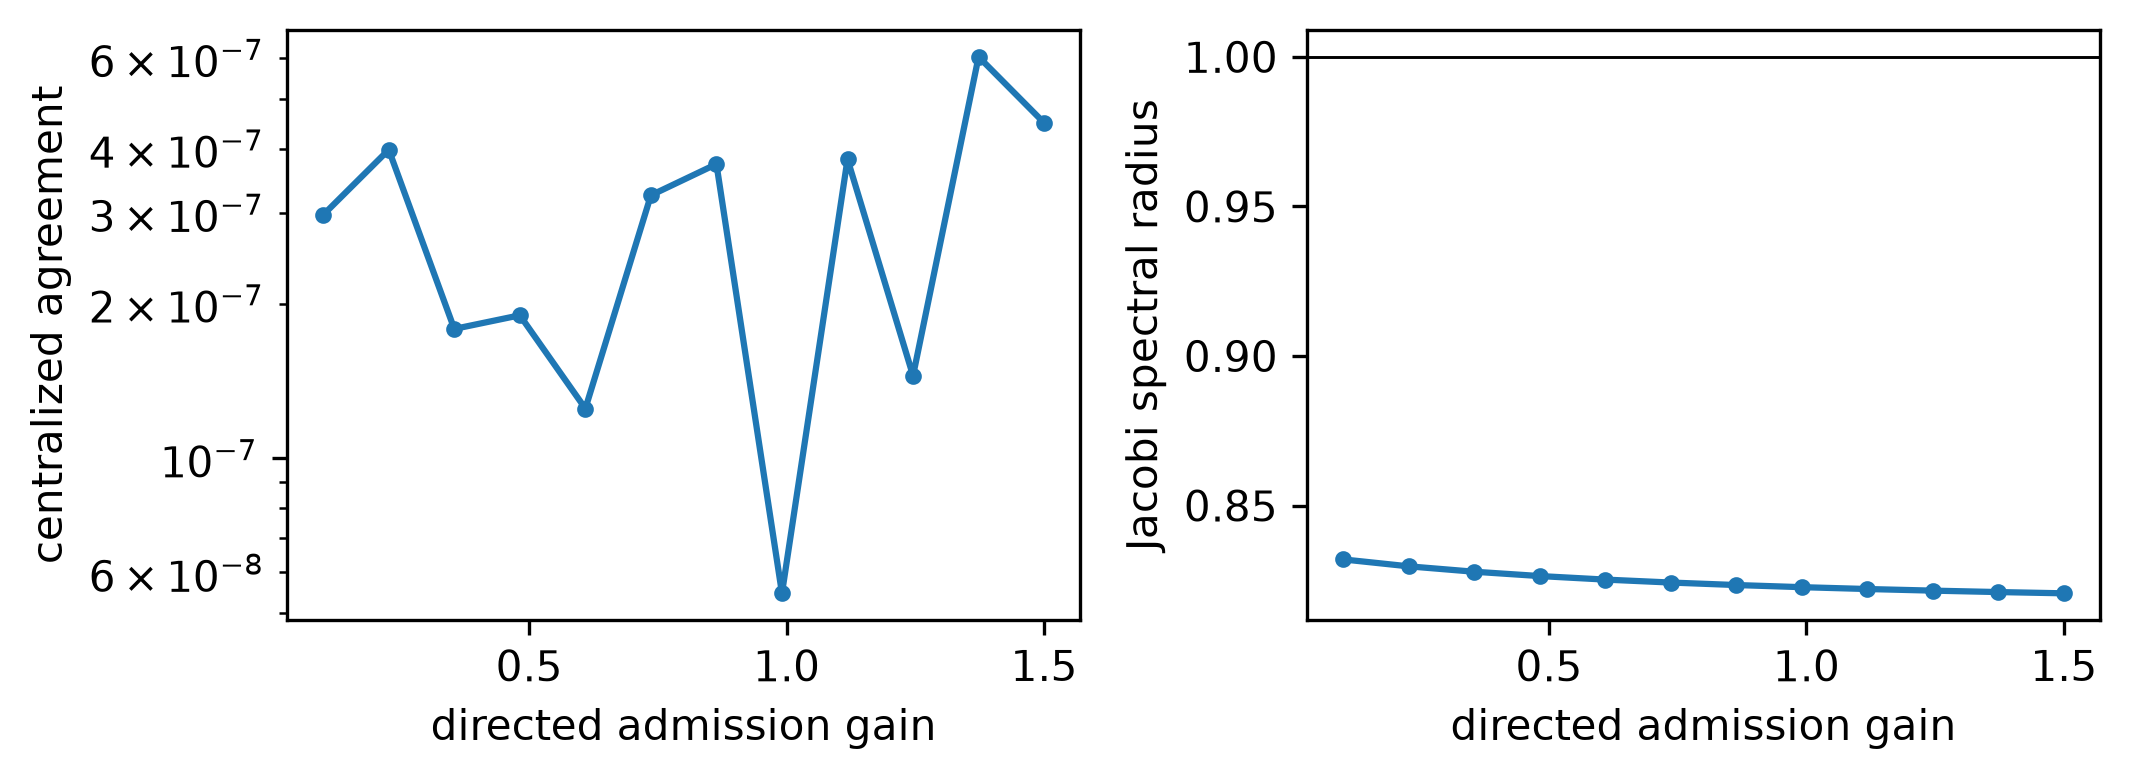

In [5]:
gains = torch.linspace(0.1, 1.5, 12)
agreement, radii = [], []
for gain in gains:
    admission = data.admission.clone()
    admission[1, 0, :] = gain
    value = model(
        data.anchors,
        data.anchor_precision,
        data.observations,
        data.observation_precision,
        admission,
        emission=data.emission,
        return_result=True,
    )
    agreement.append(float(value.agreement_error))
    radii.append(value.certificate.jacobi_spectral_radius)

figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
axes[0].semilogy(gains, agreement, marker="o", ms=3)
axes[0].set(xlabel="directed admission gain", ylabel="centralized agreement")
axes[1].plot(gains, radii, marker="o", ms=3)
axes[1].axhline(1.0, color="black", lw=0.7)
axes[1].set(xlabel="directed admission gain", ylabel="Jacobi spectral radius")
figure.tight_layout()
plt.show()

## 4. Source-Scale Verification

Reproduce the paper's carrier chain, forwarding, asymmetry, anchor-density,
latency, noisy estimation, and confidentiality-probe sweeps. Preserve typed
lineage and source-novel forwarding in the policy layer. For every run, save the
admission/emission support, centralized optimum, M-matrix certificate, recovery
error, spectral gap, message count, and random seed. The compact builder is
synthetic by design, so large source-scale runs require compute rather than a
large external dataset.

## Source Data and Full Experiment Preflight

The paper cases [[63]](https://jseluis.github.io/silva-networks/paper/references/#ref-63) are generated from declared topology, typed evidence, precision, policy, and seed. Sweep a small carrier graph against the centralized solve before increasing node counts and retained policy traces.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [6]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_mesh_inference')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://arxiv.org/abs/2606.19537
 - https://github.com/sym-bot/mesh-memory-protocol
access:
 - The reported linear-Gaussian cases are synthetic and can be regenerated from declared topology, precision, policy, and seed.
 - No private node state is needed in a shared archive; store admitted typed observations and lineage separately.
storage:
 - Storage scales with runs * typed observations * nodes plus sparse carrier edges and lineage records.
 - Stream policy sweeps because centralized matrices and distributed traces can be regenerated from the saved seed and parameters.
source-scale steps:
 1. Generate topology, typed observations, precisions, admission/emission policies, lineage, and seeds as a versioned case table.
 2. Run distributed relaxation and the centralized solve for every case, retaining the M-matrix and spectral-radius certificates.
 3. Sweep connectivity, asymmetry, noise, anchor density, latency, and forwarding while reporting agreement and communication

## From 32 Silva Mesh Inference to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one latent vector per node or entity |
| Condition | node features, edges, edge attributes, and graph batches |
| Repeated computation | a source-injected graph message or monotone graph transition |
| Required invariants | node relabeling equivariance, graph boundaries, and state shape |
| Replaceable components | input projection, message field, global field, transition, pooling, and head |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Local Observation and Relaxation Maps

```python
model = SILVAMeshInference(
    admission=my_nonnegative_admission,
    emission=my_nonnegative_emission,
    local_precision=my_precision_operator,
    coupling=my_typed_mesh_coupling,
    damping=damping,
    config=solver_config,
)
```

Each node consumes only typed neighboring observations. Keep the centralized
quadratic system as an independent reference and verify the M-matrix
certificate before scaling node count, graph degree, or observation dimension.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**node/graph error, physical graph residual, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **node count, edge count, feature width, and number of graphs**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '32_silva_mesh_inference.ipynb',
    "state": 'one latent vector per node or entity',
    "condition": 'node features, edges, edge attributes, and graph batches',
    "transition": 'a source-injected graph message or monotone graph transition',
    "invariants": 'node relabeling equivariance, graph boundaries, and state shape',
    "compact_metric": 'node/graph error, physical graph residual, and fixed-point residual',
    "scale_axis": 'node count, edge count, feature width, and number of graphs',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '32_silva_mesh_inference.ipynb',
 'state': 'one latent vector per node or entity',
 'condition': 'node features, edges, edge attributes, and graph batches',
 'transition': 'a source-injected graph message or monotone graph transition',
 'invariants': 'node relabeling equivariance, graph boundaries, and state shape',
 'compact_metric': 'node/graph error, physical graph residual, and fixed-point residual',
 'scale_axis': 'node count, edge count, feature width, and number of graphs'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **graph propagation factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **one latent vector per node or entity**, and its repeated map,
**a source-injected graph message or monotone graph transition**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [9]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('graph propagation factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


graph propagation factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


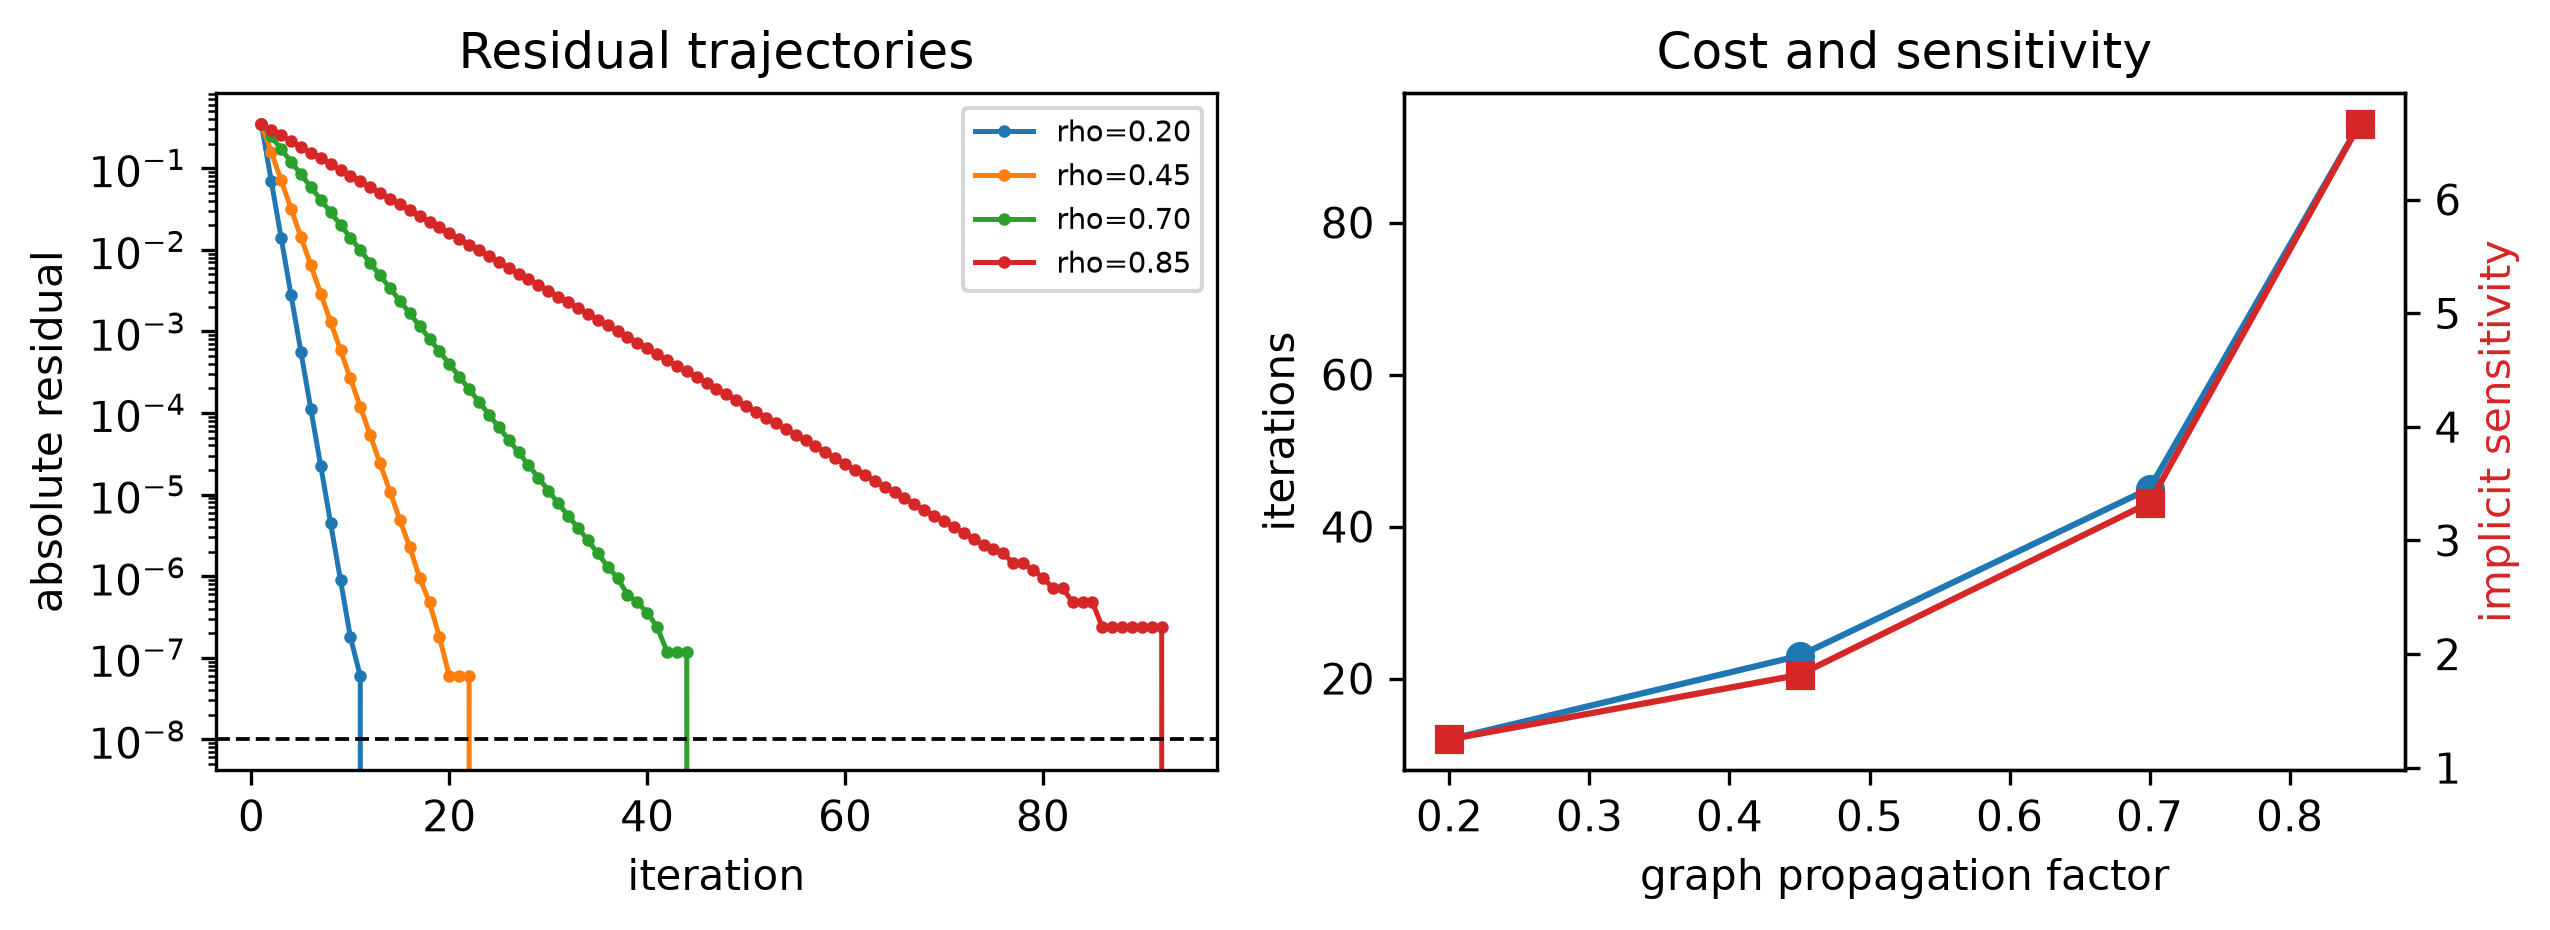

In [10]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('graph propagation factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the graph propagation factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | node/graph error, physical graph residual, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | node relabeling equivariance, graph boundaries, and state shape |
| Scale sweep | Change one of node count, edge count, feature width, and number of graphs at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is distributed relaxation compared with the centralized optimum? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#mesh-inference) |
| Which mesh transition and convergence certificate are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| How is the compact Gaussian mesh problem generated? | [Emerging Data API](https://jseluis.github.io/silva-networks/api/emerging_data/) |
